# 02 -- Feature Engineering
## RobynMMM -- Business Scientist MCE -- Ekimetrics

**Objectif :** transformer les depenses media brutes en features qui capturent la vraie dynamique causale : memoire (adstock) et rendement decroissant (saturation).

---
### Plan
1. Rappel des donnees
2. Adstock (Koyck decay)
3. Saturation (Hill function)
4. Visualisation du pipeline complet
5. Comparaison correlations avant/apres
6. Export du dataset transforme

## 0. Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

DATA_PATH = Path("../data/raw/dt_simulated_weekly.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)
df = df.rename(columns={"DATE": "date"})

MEDIA_COLS = ["tv_S", "ooh_S", "print_S", "facebook_S", "search_S"]
MEDIA_LABELS = {"tv_S":"TV","ooh_S":"OOH","print_S":"Print","facebook_S":"Facebook","search_S":"Search"}
MEDIA_COLORS = {"tv_S":"#4E9AF1","ooh_S":"#F5C842","print_S":"#6BCB77","facebook_S":"#FF7043","search_S":"#9C5CF5"}
media_present = [c for c in MEDIA_COLS if c in df.columns]

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)
print(f"[OK] Donnees chargees : {df.shape}")
print(f"Canaux : {media_present}")

[OK] Donnees chargees : (208, 12)
Canaux : ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S']


## 1. Adstock -- memoire de la publicite

### Concept

Quand une marque diffuse une pub TV cette semaine, l'effet ne disparait pas instantanement. Le spectateur se souvient du message les semaines suivantes. Cet effet residuel decroit progressivement.

### Formule de Koyck

```
adstock(t) = spend(t) + lambda * adstock(t-1)
```

- `lambda` in [0,1] : taux de retention
- `lambda = 0` : aucune memoire (effet instantane)
- `lambda = 0.65` : 65% de l'effet persiste chaque semaine
- `demi-vie = log(0.5) / log(lambda)` : semaines pour diviser l'effet par 2

In [2]:
def adstock_geometric(x, decay):
    n = len(x)
    result = np.zeros(n)
    result[0] = x[0]
    for t in range(1, n):
        result[t] = x[t] + decay * result[t - 1]
    return result

def half_life(decay):
    if decay <= 0 or decay >= 1:
        return 0.0 if decay <= 0 else float("inf")
    return np.log(0.5) / np.log(decay)

ADSTOCK_DECAY = {
    "tv_S":       0.65,
    "ooh_S":      0.40,
    "print_S":    0.60,
    "facebook_S": 0.40,
    "search_S":   0.20,
}

print("=== Parametres Adstock ===")
print(f"{'Canal':<14} {'Lambda':<12} {'Demi-vie'}")
print("-" * 38)
for col in media_present:
    d = ADSTOCK_DECAY[col]
    print(f"{MEDIA_LABELS[col]:<14} {d:<12.2f} {half_life(d):.1f} semaines")

=== Parametres Adstock ===
Canal          Lambda       Demi-vie
--------------------------------------
TV             0.65         1.6 semaines
OOH            0.40         0.8 semaines
Print          0.60         1.4 semaines
Facebook       0.40         0.8 semaines
Search         0.20         0.4 semaines


In [3]:
df_adstock = df[["date","revenue"] + media_present].copy()
for col in media_present:
    df_adstock[f"{col}_adstock"] = adstock_geometric(df[col].values, ADSTOCK_DECAY[col])
    print(f"[OK] {MEDIA_LABELS[col]:<12} mean brut={df[col].mean():.0f}  mean adstock={df_adstock[f'{col}_adstock'].mean():.0f}")

[OK] TV           mean brut=14844  mean adstock=42290
[OK] OOH          mean brut=43218  mean adstock=72023
[OK] Print        mean brut=3729  mean adstock=9273
[OK] Facebook     mean brut=2146  mean adstock=3536
[OK] Search       mean brut=5916  mean adstock=7389


### Reponse impulsionnelle : propagation d'un choc de 100k EUR

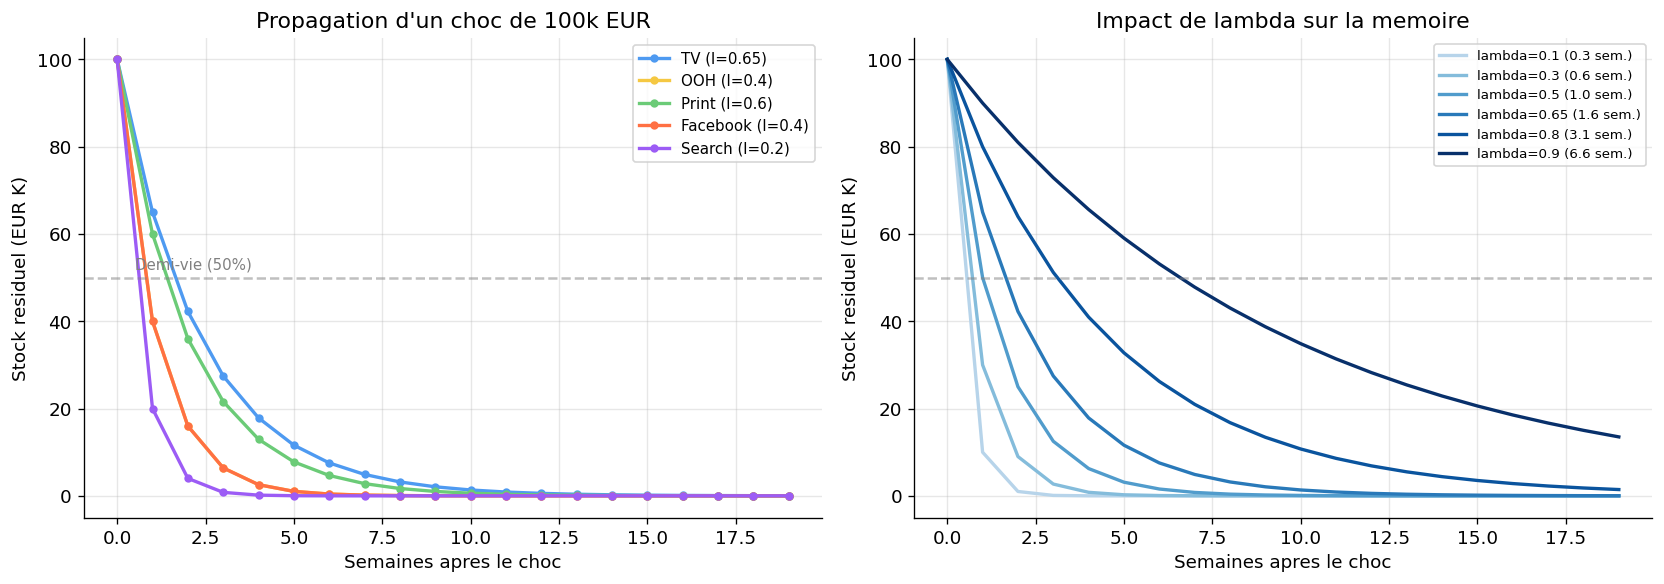

[OK] Figure sauvegardee


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

impulse = np.zeros(20)
impulse[0] = 100000

ax = axes[0]
for col in media_present:
    resp = adstock_geometric(impulse, ADSTOCK_DECAY[col])
    ax.plot(range(20), resp/1000, marker="o", markersize=4,
            label=f"{MEDIA_LABELS[col]} (l={ADSTOCK_DECAY[col]})",
            color=MEDIA_COLORS[col], linewidth=2)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax.annotate("Demi-vie (50%)", xy=(0.5, 52), fontsize=9, color="gray")
ax.set_xlabel("Semaines apres le choc")
ax.set_ylabel("Stock residuel (EUR K)")
ax.set_title("Propagation d'un choc de 100k EUR")
ax.legend(fontsize=9)

ax2 = axes[1]
lambdas = [0.1, 0.3, 0.5, 0.65, 0.8, 0.9]
colors_l = plt.cm.Blues(np.linspace(0.3, 1.0, len(lambdas)))
for lam, col in zip(lambdas, colors_l):
    resp = adstock_geometric(impulse, lam)
    ax2.plot(range(20), resp/1000,
             label=f"lambda={lam} ({half_life(lam):.1f} sem.)", color=col, linewidth=2)
ax2.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Semaines apres le choc")
ax2.set_ylabel("Stock residuel (EUR K)")
ax2.set_title("Impact de lambda sur la memoire")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/02_adstock_intuition.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

### Brut vs adstocke par canal

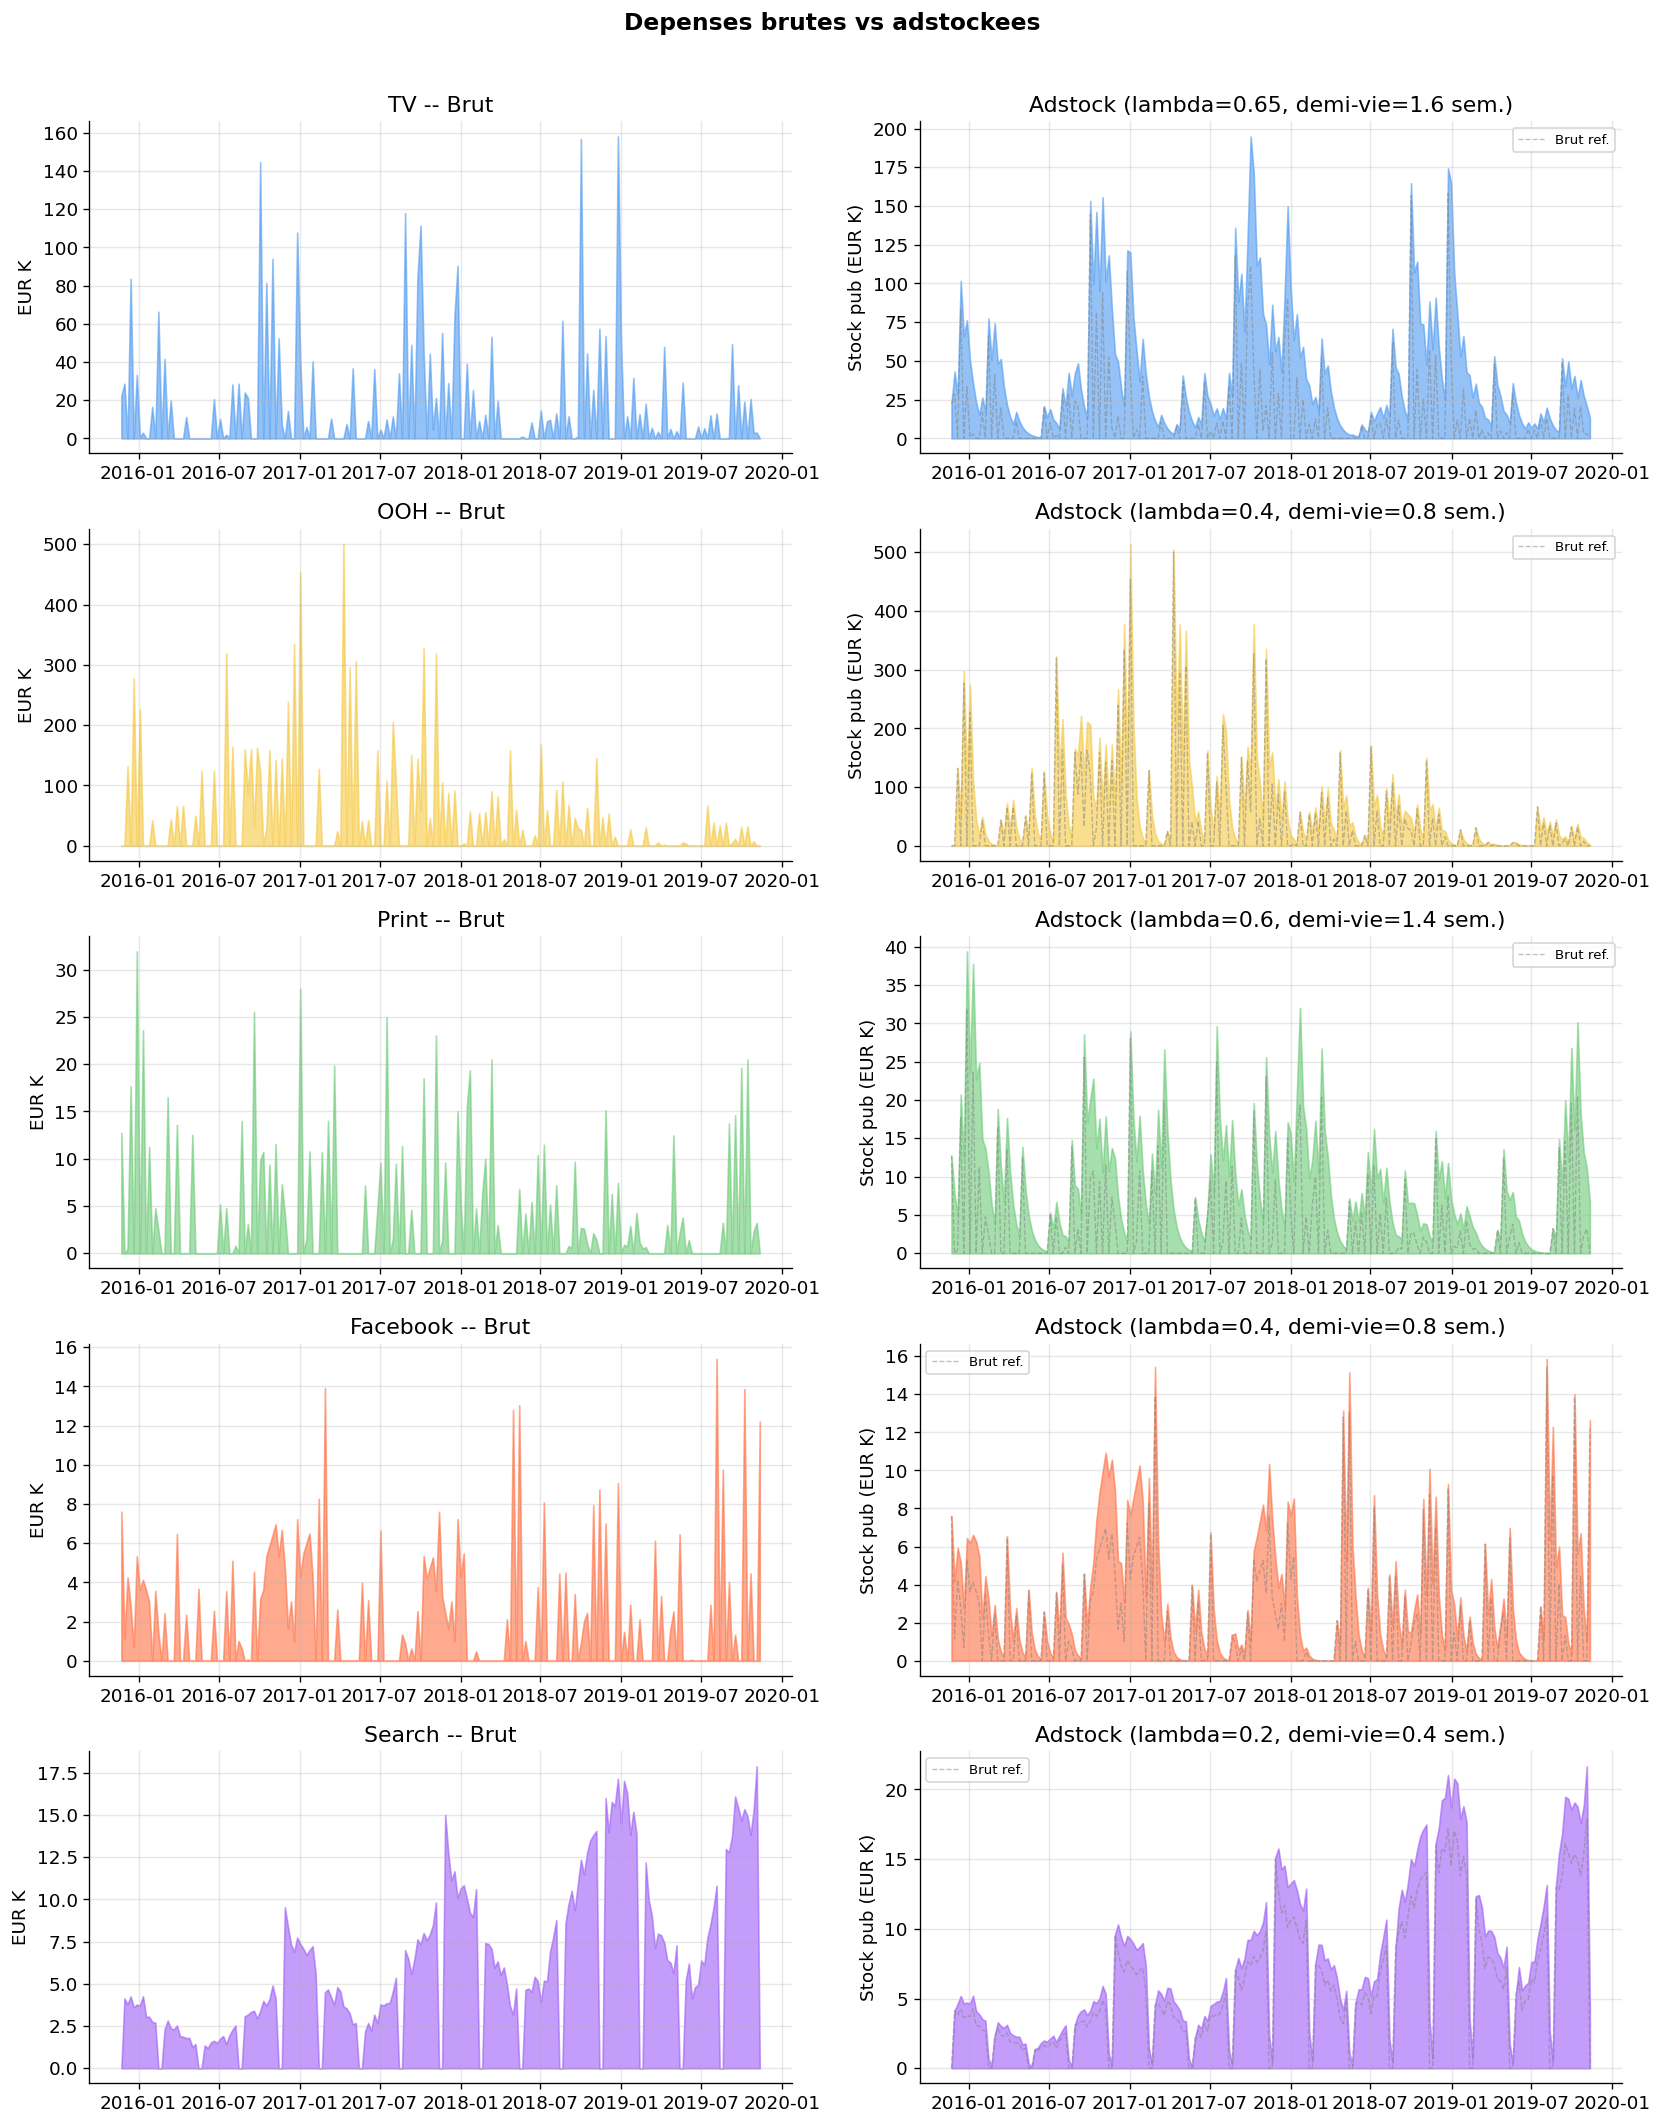

[OK] Figure sauvegardee


In [5]:
fig, axes = plt.subplots(len(media_present), 2, figsize=(14, 3.5*len(media_present)))
fig.suptitle("Depenses brutes vs adstockees", fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(media_present):
    color = MEDIA_COLORS[col]
    label = MEDIA_LABELS[col]
    d = ADSTOCK_DECAY[col]
    hl = half_life(d)

    axes[i,0].fill_between(df["date"], df[col]/1000, alpha=0.6, color=color)
    axes[i,0].set_title(f"{label} -- Brut")
    axes[i,0].set_ylabel("EUR K")

    axes[i,1].fill_between(df["date"], df_adstock[f'{col}_adstock']/1000, alpha=0.6, color=color)
    axes[i,1].plot(df["date"], df[col]/1000, color="gray", linewidth=0.8, linestyle="--", alpha=0.5, label="Brut ref.")
    axes[i,1].set_title(f"Adstock (lambda={d}, demi-vie={hl:.1f} sem.)")
    axes[i,1].set_ylabel("Stock pub (EUR K)")
    axes[i,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/02_adstock.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 2. Saturation -- rendement decroissant

### Concept

Depenser 200k en TV ne genere pas 2x plus de ventes que 100k. Au-dela d'un seuil, les consommateurs ont deja ete exposes -- l'effet marginal de chaque euro supplementaire diminue.

### Hill function

```
sat(x) = x^alpha / (x^alpha + gamma^alpha)
```

- Retourne toujours une valeur entre 0 et 1
- `alpha` : forme de la courbe (>1 = forme en S)
- `gamma` : valeur de x ou l'effet atteint 50% -- point d inflexion en EUR

In [6]:
def hill_function(x, alpha, gamma):
    x = np.maximum(x, 0)
    return x**alpha / (x**alpha + gamma**alpha)

HILL_ALPHA = {
    "tv_S": 2.0, "ooh_S": 1.5, "print_S": 1.2,
    "facebook_S": 2.5, "search_S": 1.8,
}
HILL_GAMMA = {
    "tv_S": 40000, "ooh_S": 80000, "print_S": 8000,
    "facebook_S": 5000, "search_S": 10000,
}

print("=== Parametres Saturation ===")
print(f"{'Canal':<14} {'Alpha':>8} {'Gamma (EUR)':>14}")
print("-" * 38)
for col in media_present:
    print(f"{MEDIA_LABELS[col]:<14} {HILL_ALPHA[col]:>8.1f} {HILL_GAMMA[col]:>14,.0f}")

=== Parametres Saturation ===
Canal             Alpha    Gamma (EUR)
--------------------------------------
TV                  2.0         40,000
OOH                 1.5         80,000
Print               1.2          8,000
Facebook            2.5          5,000
Search              1.8         10,000


### Courbes de saturation theoriques

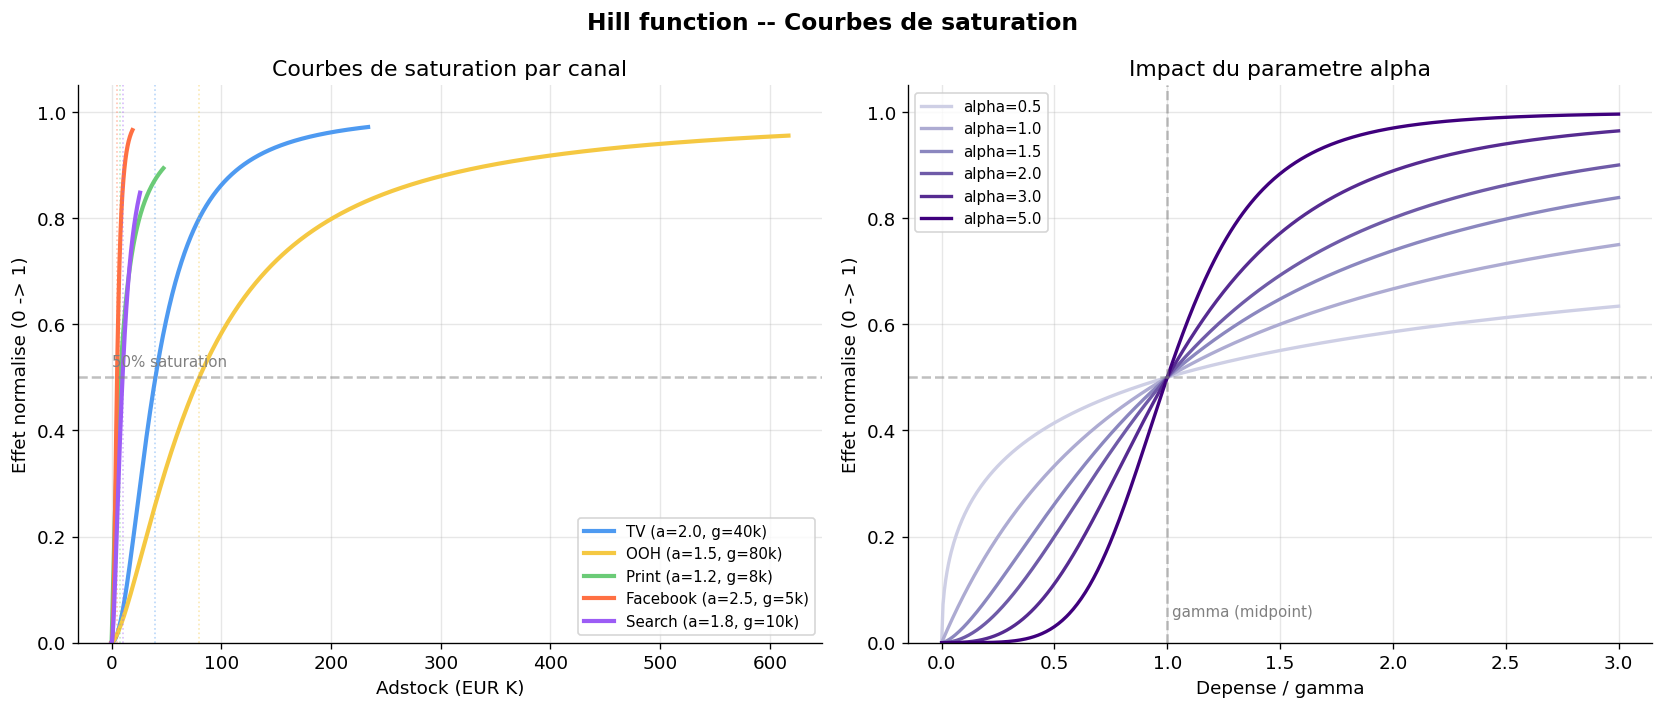

[OK] Figure sauvegardee


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Hill function -- Courbes de saturation", fontsize=14, fontweight="bold")

ax = axes[0]
for col in media_present:
    a = HILL_ALPHA[col]
    g = HILL_GAMMA[col]
    x_max = df_adstock[f"{col}_adstock"].max() * 1.2
    x_range = np.linspace(0, x_max, 500)
    y = hill_function(x_range, a, g)
    ax.plot(x_range/1000, y,
            label=f"{MEDIA_LABELS[col]} (a={a}, g={g/1000:.0f}k)",
            color=MEDIA_COLORS[col], linewidth=2.5)
    ax.axvline(x=g/1000, color=MEDIA_COLORS[col], linestyle=":", alpha=0.4, linewidth=1)

ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax.annotate("50% saturation", xy=(0, 0.52), fontsize=9, color="gray")
ax.set_xlabel("Adstock (EUR K)")
ax.set_ylabel("Effet normalise (0 -> 1)")
ax.set_title("Courbes de saturation par canal")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

ax2 = axes[1]
x_norm = np.linspace(0, 3, 500)
alphas_test = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
colors_a = plt.cm.Purples(np.linspace(0.3, 1.0, len(alphas_test)))
for a, col in zip(alphas_test, colors_a):
    y = hill_function(x_norm, a, 1.0)
    ax2.plot(x_norm, y, label=f"alpha={a}", color=col, linewidth=2)
ax2.axvline(x=1.0, color="gray", linestyle="--", alpha=0.5)
ax2.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax2.annotate("gamma (midpoint)", xy=(1.02, 0.05), fontsize=9, color="gray")
ax2.set_xlabel("Depense / gamma")
ax2.set_ylabel("Effet normalise (0 -> 1)")
ax2.set_title("Impact du parametre alpha")
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../outputs/figures/02_saturation_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 3. Pipeline complet : brut -> adstock -> transforme

In [8]:
df_features = df_adstock.copy()
for col in media_present:
    ads = df_adstock[f"{col}_adstock"].values
    df_features[f"{col}_transformed"] = hill_function(ads, HILL_ALPHA[col], HILL_GAMMA[col])
    print(f"[OK] {MEDIA_LABELS[col]:<12} saturation moyenne = {df_features[f'{col}_transformed'].mean():.3f}/1.0")

[OK] TV           saturation moyenne = 0.393/1.0
[OK] OOH          saturation moyenne = 0.326/1.0
[OK] Print        saturation moyenne = 0.447/1.0
[OK] Facebook     saturation moyenne = 0.286/1.0
[OK] Search       saturation moyenne = 0.327/1.0


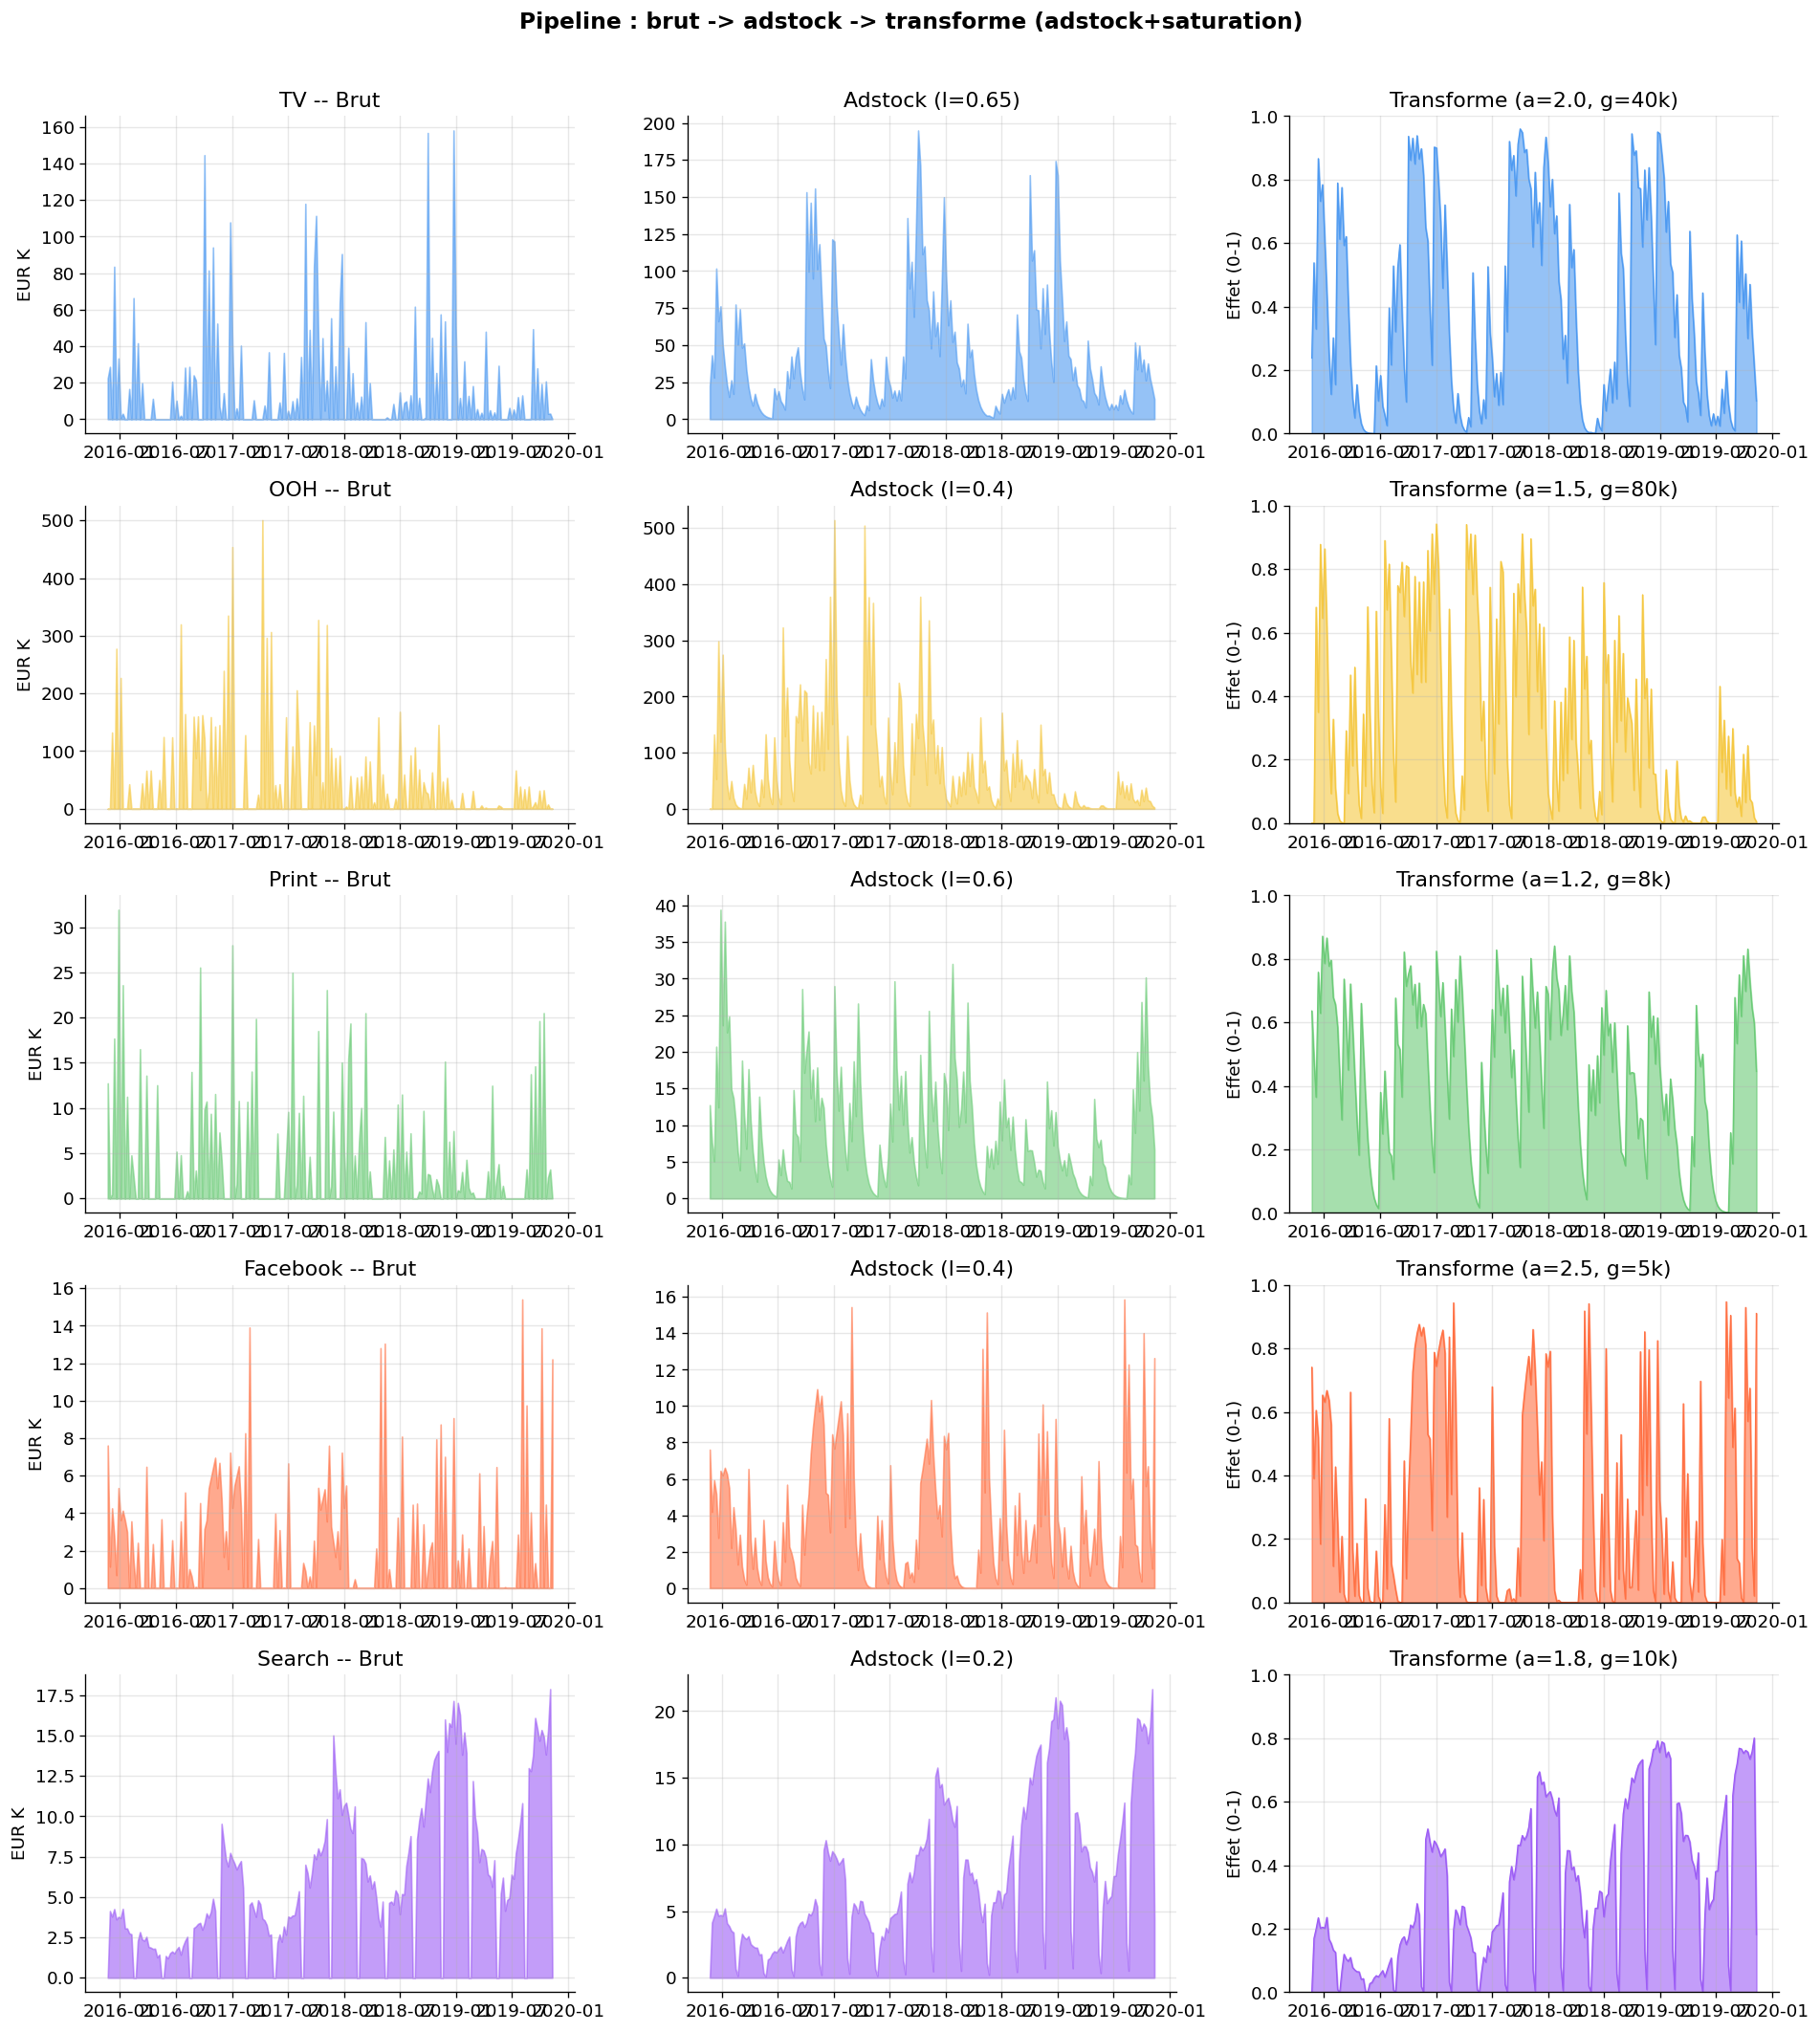

[OK] Figure sauvegardee


In [9]:
fig, axes = plt.subplots(len(media_present), 3, figsize=(16, 3.5*len(media_present)))
fig.suptitle("Pipeline : brut -> adstock -> transforme (adstock+saturation)",
             fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(media_present):
    color = MEDIA_COLORS[col]
    label = MEDIA_LABELS[col]

    axes[i,0].fill_between(df["date"], df[col]/1000, alpha=0.6, color=color)
    axes[i,0].set_title(f"{label} -- Brut")
    axes[i,0].set_ylabel("EUR K")

    axes[i,1].fill_between(df["date"], df_adstock[f'{col}_adstock']/1000, alpha=0.6, color=color)
    axes[i,1].set_title(f"Adstock (l={ADSTOCK_DECAY[col]})")

    axes[i,2].fill_between(df["date"], df_features[f'{col}_transformed'], alpha=0.6, color=color)
    axes[i,2].plot(df["date"], df_features[f'{col}_transformed'], color=color, linewidth=0.8)
    axes[i,2].set_title(f"Transforme (a={HILL_ALPHA[col]}, g={HILL_GAMMA[col]/1000:.0f}k)")
    axes[i,2].set_ylabel("Effet (0-1)")
    axes[i,2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../outputs/figures/02_pipeline_complet.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 4. Comparaison correlations avant / apres

In [10]:
corr_brut  = {col: df[col].corr(df["revenue"]) for col in media_present}
corr_trans = {col: df_features[f"{col}_transformed"].corr(df["revenue"]) for col in media_present}

print("=" * 58)
print("  IMPACT DES TRANSFORMATIONS SUR LA CORRELATION")
print("=" * 58)
print(f"{'Canal':<14} {'Brut':>10} {'Transforme':>12} {'Gain':>8}")
print("-" * 46)
for col in media_present:
    av = corr_brut[col]
    ap = corr_trans[col]
    gain = ap - av
    sign = "+" if gain > 0 else ""
    print(f"{MEDIA_LABELS[col]:<14} {av:>+10.3f} {ap:>+12.3f} {sign}{gain:>+7.3f}")

  IMPACT DES TRANSFORMATIONS SUR LA CORRELATION
Canal                Brut   Transforme     Gain
----------------------------------------------
TV                 +0.420       +0.731 + +0.311
OOH                +0.095       +0.220 + +0.124
Print              +0.230       +0.384 + +0.153
Facebook           +0.318       +0.479 + +0.162
Search             +0.443       +0.452 + +0.009


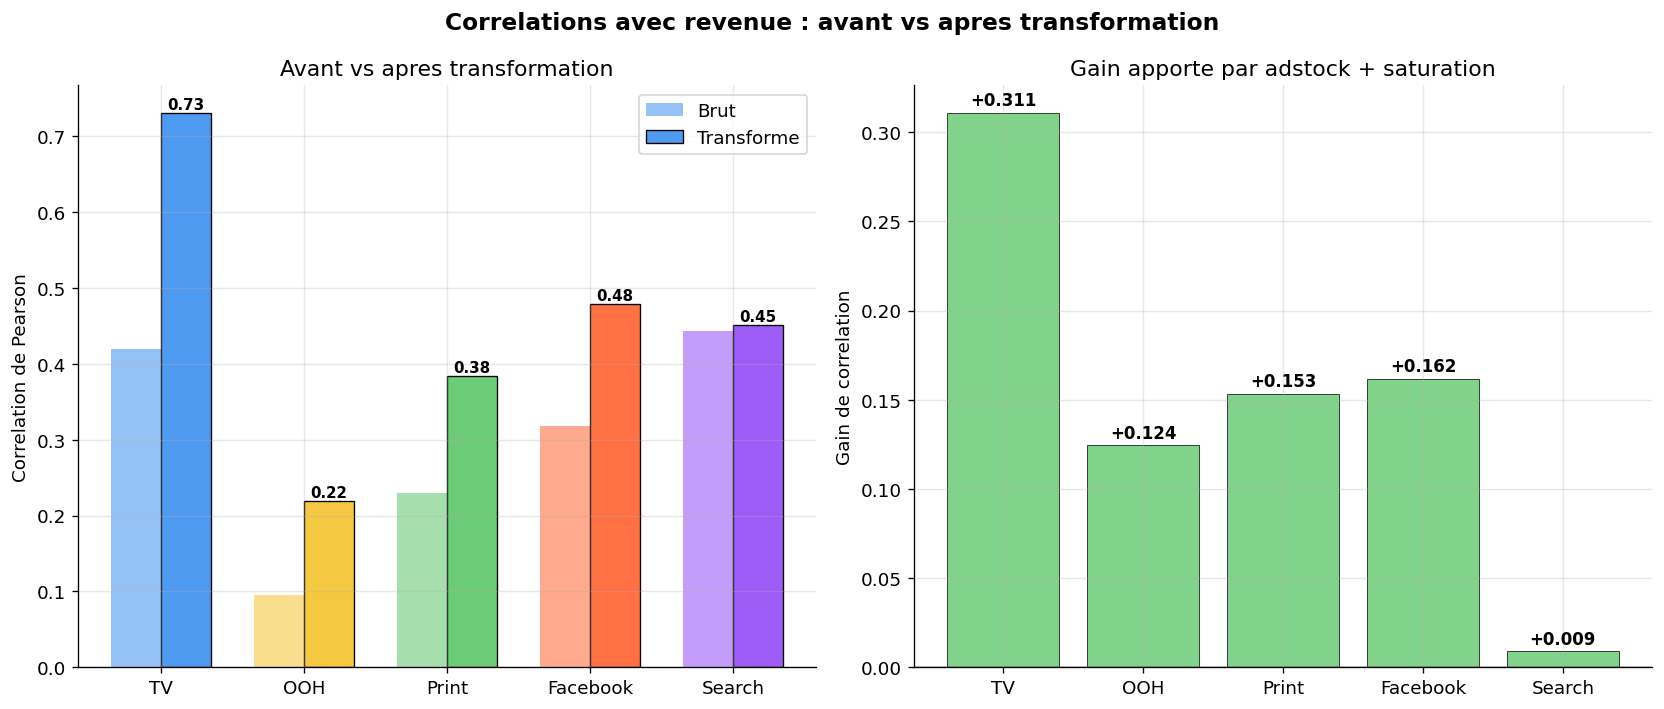

[OK] Figure sauvegardee


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Correlations avec revenue : avant vs apres transformation", fontsize=14, fontweight="bold")

labels = [MEDIA_LABELS[c] for c in media_present]
avant_vals = [corr_brut[c] for c in media_present]
apres_vals = [corr_trans[c] for c in media_present]
x = np.arange(len(media_present))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, avant_vals, width, label="Brut", alpha=0.6,
       color=[MEDIA_COLORS[c] for c in media_present])
bars2 = ax.bar(x + width/2, apres_vals, width, label="Transforme", alpha=1.0,
               color=[MEDIA_COLORS[c] for c in media_present], edgecolor="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Correlation de Pearson")
ax.set_title("Avant vs apres transformation")
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.2f}", ha="center", fontsize=9, fontweight="bold")

ax2 = axes[1]
gains = [apres_vals[i] - avant_vals[i] for i in range(len(media_present))]
colors_gain = ["#6BCB77" if g > 0 else "#FF7043" for g in gains]
bars = ax2.bar(labels, gains, color=colors_gain, alpha=0.85, edgecolor="black", linewidth=0.5)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_ylabel("Gain de correlation")
ax2.set_title("Gain apporte par adstock + saturation")
for bar, val in zip(bars, gains):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002 * np.sign(val),
             f"{val:+.3f}", ha="center",
             va="bottom" if val > 0 else "top", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/02_correlation_avant_apres.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 5. Export du dataset transforme

In [15]:
# Colonnes de controle disponibles
control_cols = [c for c in ["events", "newsletter", "competitor_sales_B"] 
                if c in df.columns]

# df_features contient les transformed mais pas les adstock
# On les ajoute depuis df_adstock
for col in media_present:
    adstock_col = f"{col}_adstock"
    if adstock_col in df_adstock.columns and adstock_col not in df_features.columns:
        df_features[adstock_col] = df_adstock[adstock_col].values

# Colonnes disponibles dans df_features
adstock_available    = [f"{c}_adstock"     for c in media_present if f"{c}_adstock"     in df_features.columns]
transformed_available= [f"{c}_transformed" for c in media_present if f"{c}_transformed" in df_features.columns]

cols_final = (
    ["date", "revenue"]
    + media_present
    + adstock_available
    + transformed_available
    + [c for c in control_cols if c in df_features.columns]
)

df_final = df_features[cols_final].copy()
df_final["trend"]        = np.arange(len(df_final))
df_final["month"]        = df["date"].dt.month
df_final["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

out_path = Path("../data/processed/dt_features.parquet")
df_final.to_parquet(out_path, index=False)
print(f"[OK] Dataset sauvegarde : {out_path}")
print(f"Shape : {df_final.shape[0]} lignes x {df_final.shape[1]} colonnes")
print(f"\nColonnes exportees :")
for c in df_final.columns:
    print(f"  {c}")

[OK] Dataset sauvegarde : ../data/processed/dt_features.parquet
Shape : 208 lignes x 20 colonnes

Colonnes exportees :
  date
  revenue
  tv_S
  ooh_S
  print_S
  facebook_S
  search_S
  tv_S_adstock
  ooh_S_adstock
  print_S_adstock
  facebook_S_adstock
  search_S_adstock
  tv_S_transformed
  ooh_S_transformed
  print_S_transformed
  facebook_S_transformed
  search_S_transformed
  trend
  month
  week_of_year


## 6. Synthese

In [16]:
print("=" * 62)
print("  SYNTHESE -- Feature Engineering")
print("=" * 62)
print()
print("ADSTOCK (memoire):")
for col in media_present:
    d = ADSTOCK_DECAY[col]
    hl = half_life(d)
    print(f"  {MEDIA_LABELS[col]:<14} lambda={d}  demi-vie={hl:.1f} sem.")
print()
print("SATURATION (rendement decroissant):")
for col in media_present:
    a = HILL_ALPHA[col]
    g = HILL_GAMMA[col]
    print(f"  {MEDIA_LABELS[col]:<14} alpha={a}  gamma={g/1000:.0f}k EUR")
print()
print("IMPACT SUR LES CORRELATIONS AVEC REVENUE:")
print(f"  {'Canal':<14} {'Brut':>8} {'Final':>8} {'Gain':>8}")
print("  " + "-" * 40)
for col in media_present:
    av = corr_brut[col]
    ap = corr_trans[col]
    print(f"  {MEDIA_LABELS[col]:<14} {av:>+8.3f} {ap:>+8.3f} {ap-av:>+8.3f}")
print()
print("PROCHAINE ETAPE --> Notebook 03 : Modele OLS")
print("  - Regression avec statsmodels sur features transformees")
print("  - R2, p-values, diagnostics des residus")
print("  - Decomposition des contributions par canal")
print("=" * 62)

  SYNTHESE -- Feature Engineering

ADSTOCK (memoire):
  TV             lambda=0.65  demi-vie=1.6 sem.
  OOH            lambda=0.4  demi-vie=0.8 sem.
  Print          lambda=0.6  demi-vie=1.4 sem.
  Facebook       lambda=0.4  demi-vie=0.8 sem.
  Search         lambda=0.2  demi-vie=0.4 sem.

SATURATION (rendement decroissant):
  TV             alpha=2.0  gamma=40k EUR
  OOH            alpha=1.5  gamma=80k EUR
  Print          alpha=1.2  gamma=8k EUR
  Facebook       alpha=2.5  gamma=5k EUR
  Search         alpha=1.8  gamma=10k EUR

IMPACT SUR LES CORRELATIONS AVEC REVENUE:
  Canal              Brut    Final     Gain
  ----------------------------------------
  TV               +0.420   +0.731   +0.311
  OOH              +0.095   +0.220   +0.124
  Print            +0.230   +0.384   +0.153
  Facebook         +0.318   +0.479   +0.162
  Search           +0.443   +0.452   +0.009

PROCHAINE ETAPE --> Notebook 03 : Modele OLS
  - Regression avec statsmodels sur features transformees
  - R2, p-v